In [1]:
import json
import pymysql
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pymongo import MongoClient

In [2]:
def get_local():
    with open("../auth.json", "r") as f:
        auth = json.load(f)["local"]
        uri = f'mongodb://{auth["username"]}:{auth["password"]}@{auth["host"]}:{auth["port"]}/{auth["database"]}'
        conn = MongoClient(uri)[auth["database"]]
    return conn

def get_remote():
    with open("../auth.json", "r") as f:
        auth = json.load(f)["remote"]
        conn = pymysql.connect(
            host=auth["host"], port=auth["port"], user=auth["username"], password=auth["password"],
            database=auth["database"], charset=auth["charset"], cursorclass=pymysql.cursors.DictCursor
       )
    return conn

In [3]:
remote = get_remote()

### MPM310

In [4]:
sql = f'SELECT * FROM mpm310_sang WHERE farmid = "0005" ORDER BY rcvtime ASC;'

In [5]:
with remote.cursor() as cursor:
    cursor.execute(sql)
    results = cursor.fetchall()

In [6]:
mpm310 = pd.DataFrame(list(results))

In [7]:
mpm310

,devid,rcvtime,farmid,voltage,current,activepower,reactivepower,apparentpower,frequency,powerfactor,actelectric,reaelectric,peakactive,peakcurrent
0,2,20260522131237,0005,226.57,3.26,0.71,0.15,0.72,60.0,0.98,1,0,1.100,5.002
1,2,20260522131358,0005,226.57,19.45,4.22,0.85,4.30,60.0,0.98,1,0,4.248,19.560
2,2,20260522131452,0005,226.33,19.48,4.23,0.85,4.31,60.0,0.98,1,0,4.248,19.572
3,2,20260522131546,0005,226.17,19.47,4.22,0.85,4.31,60.0,0.98,1,0,4.248,19.602
4,2,20260522131640,0005,226.54,19.52,4.23,0.86,4.32,60.0,0.98,1,0,4.248,19.602
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131560,3,20260604144403,0005,228.92,0.00,0.00,0.00,0.00,60.0,0.00,355,74,4.308,20.166
131561,2,20260604144403,0005,228.28,0.00,0.00,0.00,0.00,60.0,0.00,353,72,4.290,19.956
131562,4,20260604144404,0005,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0,0,1.653,5.018
131563,5,20260604144406,0005,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0,0,1.102,5.004


In [8]:
# 1. rcvtime을 datetime으로 변환
mpm310["rcv_dt"] = pd.to_datetime(
    mpm310["rcvtime"].astype(str),
    format="%Y%m%d%H%M%S"
)

# 2. 시간순 정렬
mpm310 = mpm310.sort_values("rcv_dt").reset_index(drop=True)

# 3. 이전 수집 시각과의 차이 계산
mpm310["prev_rcv_dt"] = mpm310["rcv_dt"].shift(1)
mpm310["gap"] = mpm310["rcv_dt"] - mpm310["prev_rcv_dt"]

# 4. 크게 빈 구간만 추출
# 예: 10분 이상 비면 수집 공백으로 판단
gap_threshold = pd.Timedelta(minutes=10)

gaps = mpm310[mpm310["gap"] >= gap_threshold].copy()

# 5. 보기 좋게 정리
gaps_result = gaps[[
    "prev_rcv_dt",
    "rcv_dt",
    "gap",
    "devid",
    "farmid"
]].rename(columns={
    "prev_rcv_dt": "gap_start",
    "rcv_dt": "gap_end",
    "gap": "gap_duration"
})

print(gaps_result)

Empty DataFrame
Columns: [gap_start, gap_end, gap_duration, devid, farmid]
Index: []


In [9]:
mpm310["gap"].max()

Timedelta('0 days 00:08:08')

In [10]:
mpm310

,devid,rcvtime,farmid,voltage,current,activepower,reactivepower,apparentpower,frequency,powerfactor,actelectric,reaelectric,peakactive,peakcurrent,rcv_dt,prev_rcv_dt,gap
0,2,20260522131237,0005,226.57,3.26,0.71,0.15,0.72,60.0,0.98,1,0,1.100,5.002,2026-05-22 13:12:37,NaT,NaT
1,2,20260522131358,0005,226.57,19.45,4.22,0.85,4.30,60.0,0.98,1,0,4.248,19.560,2026-05-22 13:13:58,2026-05-22 13:12:37,0 days 00:01:21
2,2,20260522131452,0005,226.33,19.48,4.23,0.85,4.31,60.0,0.98,1,0,4.248,19.572,2026-05-22 13:14:52,2026-05-22 13:13:58,0 days 00:00:54
3,2,20260522131546,0005,226.17,19.47,4.22,0.85,4.31,60.0,0.98,1,0,4.248,19.602,2026-05-22 13:15:46,2026-05-22 13:14:52,0 days 00:00:54
4,2,20260522131640,0005,226.54,19.52,4.23,0.86,4.32,60.0,0.98,1,0,4.248,19.602,2026-05-22 13:16:40,2026-05-22 13:15:46,0 days 00:00:54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131560,3,20260604144403,0005,228.92,0.00,0.00,0.00,0.00,60.0,0.00,355,74,4.308,20.166,2026-06-04 14:44:03,2026-06-04 14:44:00,0 days 00:00:03
131561,2,20260604144403,0005,228.28,0.00,0.00,0.00,0.00,60.0,0.00,353,72,4.290,19.956,2026-06-04 14:44:03,2026-06-04 14:44:03,0 days 00:00:00
131562,4,20260604144404,0005,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0,0,1.653,5.018,2026-06-04 14:44:04,2026-06-04 14:44:03,0 days 00:00:01
131563,5,20260604144406,0005,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0,0,1.102,5.004,2026-06-04 14:44:06,2026-06-04 14:44:04,0 days 00:00:02


In [11]:
mpm310["gap"].max()

Timedelta('0 days 00:08:08')

#### mpm310 - total values

In [12]:
df_310 = mpm310[["rcv_dt", "activepower", "devid"]].copy()
df_310["rcv_h"] = df_310["rcv_dt"].dt.strftime("%Y%m%d-%H")
df_310["rcv_uh"] = df_310["rcv_dt"].dt.hour
df_310["activepower_60"] = df_310["activepower"] / 60
df_310

,rcv_dt,activepower,devid,rcv_h,rcv_uh,activepower_60
0,2026-05-22 13:12:37,0.71,2,20260522-13,13,0.01183333333333333333333333333
1,2026-05-22 13:13:58,4.22,2,20260522-13,13,0.07033333333333333333333333333
2,2026-05-22 13:14:52,4.23,2,20260522-13,13,0.0705
3,2026-05-22 13:15:46,4.22,2,20260522-13,13,0.07033333333333333333333333333
4,2026-05-22 13:16:40,4.23,2,20260522-13,13,0.0705
...,...,...,...,...,...,...
131560,2026-06-04 14:44:03,0.00,3,20260604-14,14,0.00
131561,2026-06-04 14:44:03,0.00,2,20260604-14,14,0.00
131562,2026-06-04 14:44:04,0.00,4,20260604-14,14,0.00
131563,2026-06-04 14:44:06,0.00,5,20260604-14,14,0.00


In [13]:
df_310["rcv_d"] = df_310["rcv_dt"].dt.strftime("%Y%m%d")
df_310.groupby("rcv_d")[["activepower_60"]].sum()

,activepower_60
rcv_d,
20260522,4.586833333333333333333333344
20260523,0.00
20260524,0.00
20260525,0.00
20260526,0.00
20260527,10.21150000000000000000000001
20260528,0.00
20260529,0.00
20260530,99.60916666666666666666666892


In [15]:
df_310.groupby("rcv_uh")["activepower_60"].sum()

rcv_uh
0     42.49216666666666666666666714
1     42.49000000000000000000000052
2     42.48716666666666666666666718
3     42.48483333333333333333333385
4     42.47983333333333333333333384
5     42.48666666666666666666666731
6     42.50783333333333333333333415
7     42.51500000000000000000000073
8     42.52500000000000000000000083
9     41.25016666666666666666666754
10                             0.00
11    1.989833333333333333333333334
12    7.029000000000000000000000009
13    17.91900000000000000000000025
14    13.04166666666666666666666676
15    9.222833333333333333333333342
16    42.46999999999999999999999991
17    42.49866666666666666666666707
18    42.51433333333333333333333388
19    42.51016666666666666666666719
20    42.50700000000000000000000053
21    42.50350000000000000000000048
22    42.50316666666666666666666715
23    42.50716666666666666666666709
Name: activepower_60, dtype: object

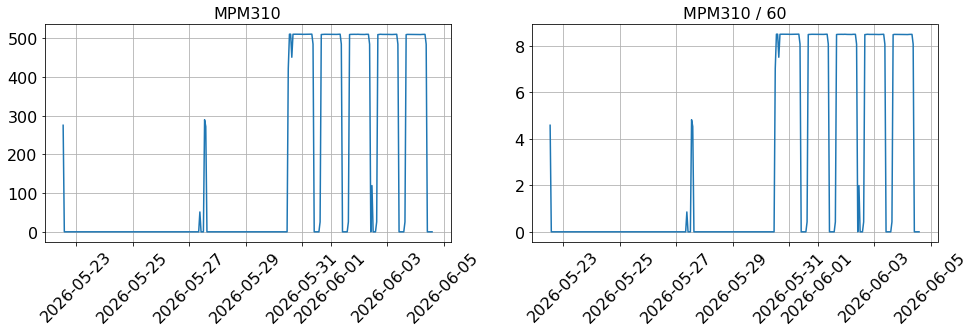

In [14]:
agg_310 = df_310.groupby("rcv_h")[["activepower", "activepower_60"]].sum()

dates = pd.to_datetime(agg_310.index, format="%Y%m%d-%H")

plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
plt.plot(dates, agg_310["activepower"].values)
plt.xticks(fontsize=16, rotation=45)
plt.yticks(fontsize=16)
plt.grid(True)
plt.title("MPM310", fontsize=16)

plt.subplot(1, 2, 2)
plt.plot(dates, agg_310["activepower_60"].values)
plt.xticks(fontsize=16, rotation=45)
plt.yticks(fontsize=16)
plt.grid(True)
plt.title("MPM310 / 60", fontsize=16)

plt.show()

## MPM330

In [15]:
sql = f'SELECT * FROM mpm330_sang WHERE farmid = "0005" ORDER BY rcvtime ASC;'

In [16]:
with remote.cursor() as cursor:
    cursor.execute(sql)
    results = cursor.fetchall()

In [17]:
mpm330 = pd.DataFrame(list(results))

In [18]:
mpm330

,devid,rcvtime,farmid,rsvoltage,stvoltage,trvoltage,rvoltage,svoltage,tvoltage,rcurrent,...,tacpower,rrepower,srepower,trepower,rappower,sappower,tappower,rpowerfactor,spowerfactor,tpowerfactor
0,0,20260522125936,0005,393.34,392.56,392.84,227.26,226.95,226.36,3.040,...,4.800,-0.080,-1.040,-0.960,0.644,4.364,4.910,654.37,654.39,617.37
1,0,20260522130036,0005,393.72,393.54,393.58,227.35,227.30,227.13,3.040,...,4.880,-0.160,-1.040,-1.040,0.658,4.364,4.910,654.37,654.39,300.89
2,0,20260522130136,0005,393.72,393.52,393.56,227.34,227.31,227.11,3.040,...,4.880,-0.080,-1.040,-1.040,0.644,4.364,4.972,654.37,654.39,422.11
3,0,20260522130236,0005,393.44,392.98,393.14,227.25,227.07,226.72,3.040,...,4.880,-0.080,-1.040,-0.960,0.644,4.364,4.972,654.37,654.39,314.76
4,0,20260522130336,0005,393.40,393.08,393.18,227.20,227.09,226.82,3.040,...,4.880,-0.080,-1.040,-0.960,0.644,4.364,4.972,654.37,654.39,453.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18775,0,20260604140154,0005,395.04,394.12,395.12,228.66,227.51,227.61,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.00,327.93
18776,0,20260604140259,0005,395.42,394.46,395.66,228.98,227.62,227.89,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.00,68.34
18777,0,20260604140355,0005,395.22,394.88,395.80,228.73,227.65,228.33,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.00,506.45
18778,0,20260604140451,0005,394.52,393.98,394.76,228.23,227.35,227.61,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.00,360.77


In [19]:
# 1. rcvtime을 datetime으로 변환
mpm330["rcv_dt"] = pd.to_datetime(
    mpm330["rcvtime"].astype(str),
    format="%Y%m%d%H%M%S"
)

# 2. 시간순 정렬
mpm330 = mpm330.sort_values("rcv_dt").reset_index(drop=True)

# 3. 이전 수집 시각과의 차이 계산
mpm330["prev_rcv_dt"] = mpm330["rcv_dt"].shift(1)
mpm330["gap"] = mpm330["rcv_dt"] - mpm330["prev_rcv_dt"]

# 4. 크게 빈 구간만 추출
# 예: 10분 이상 비면 수집 공백으로 판단
gap_threshold = pd.Timedelta(minutes=10)

gaps = mpm330[mpm330["gap"] >= gap_threshold].copy()

# 5. 보기 좋게 정리
gaps_result = gaps[[
    "prev_rcv_dt",
    "rcv_dt",
    "gap",
    "devid",
    "farmid"
]].rename(columns={
    "prev_rcv_dt": "gap_start",
    "rcv_dt": "gap_end",
    "gap": "gap_duration"
})

print(gaps_result)

Empty DataFrame
Columns: [gap_start, gap_end, gap_duration, devid, farmid]
Index: []


In [20]:
gaps_result

,gap_start,gap_end,gap_duration,devid,farmid


In [21]:
mpm330

,devid,rcvtime,farmid,rsvoltage,stvoltage,trvoltage,rvoltage,svoltage,tvoltage,rcurrent,...,trepower,rappower,sappower,tappower,rpowerfactor,spowerfactor,tpowerfactor,rcv_dt,prev_rcv_dt,gap
0,0,20260522125936,0005,393.34,392.56,392.84,227.26,226.95,226.36,3.040,...,-0.960,0.644,4.364,4.910,654.37,654.39,617.37,2026-05-22 12:59:36,NaT,NaT
1,0,20260522130036,0005,393.72,393.54,393.58,227.35,227.30,227.13,3.040,...,-1.040,0.658,4.364,4.910,654.37,654.39,300.89,2026-05-22 13:00:36,2026-05-22 12:59:36,0 days 00:01:00
2,0,20260522130136,0005,393.72,393.52,393.56,227.34,227.31,227.11,3.040,...,-1.040,0.644,4.364,4.972,654.37,654.39,422.11,2026-05-22 13:01:36,2026-05-22 13:00:36,0 days 00:01:00
3,0,20260522130236,0005,393.44,392.98,393.14,227.25,227.07,226.72,3.040,...,-0.960,0.644,4.364,4.972,654.37,654.39,314.76,2026-05-22 13:02:36,2026-05-22 13:01:36,0 days 00:01:00
4,0,20260522130336,0005,393.40,393.08,393.18,227.20,227.09,226.82,3.040,...,-0.960,0.644,4.364,4.972,654.37,654.39,453.25,2026-05-22 13:03:36,2026-05-22 13:02:36,0 days 00:01:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18775,0,20260604140154,0005,395.04,394.12,395.12,228.66,227.51,227.61,0.000,...,0.000,0.000,0.000,0.000,0.00,0.00,327.93,2026-06-04 14:01:54,2026-06-04 14:00:58,0 days 00:00:56
18776,0,20260604140259,0005,395.42,394.46,395.66,228.98,227.62,227.89,0.000,...,0.000,0.000,0.000,0.000,0.00,0.00,68.34,2026-06-04 14:02:59,2026-06-04 14:01:54,0 days 00:01:05
18777,0,20260604140355,0005,395.22,394.88,395.80,228.73,227.65,228.33,0.000,...,0.000,0.000,0.000,0.000,0.00,0.00,506.45,2026-06-04 14:03:55,2026-06-04 14:02:59,0 days 00:00:56
18778,0,20260604140451,0005,394.52,393.98,394.76,228.23,227.35,227.61,0.000,...,0.000,0.000,0.000,0.000,0.00,0.00,360.77,2026-06-04 14:04:51,2026-06-04 14:03:55,0 days 00:00:56


In [22]:
mpm330["gap"].max()

Timedelta('0 days 00:08:17')

In [23]:
df_330 = mpm330[["rcv_dt", "totalacpower", "devid"]].copy()
df_330["rcv_h"] = df_330["rcv_dt"].dt.strftime("%Y%m%d-%H")
df_330["activepower_60"] = df_330["totalacpower"] / 60
df_330

,rcv_dt,totalacpower,devid,rcv_h,activepower_60
0,2026-05-22 12:59:36,9.760,0,20260522-12,0.1626666666666666666666666667
1,2026-05-22 13:00:36,9.840,0,20260522-13,0.164
2,2026-05-22 13:01:36,9.840,0,20260522-13,0.164
3,2026-05-22 13:02:36,9.840,0,20260522-13,0.164
4,2026-05-22 13:03:36,9.840,0,20260522-13,0.164
...,...,...,...,...,...
18775,2026-06-04 14:01:54,0.000,0,20260604-14,0.000
18776,2026-06-04 14:02:59,0.000,0,20260604-14,0.000
18777,2026-06-04 14:03:55,0.000,0,20260604-14,0.000
18778,2026-06-04 14:04:51,0.000,0,20260604-14,0.000


In [24]:
df_330["rcv_d"] = df_330["rcv_dt"].dt.strftime("%Y%m%d")
df_330.groupby("rcv_d")[["activepower_60"]].sum()

,activepower_60
rcv_d,
20260522,8.428000000000000000000000007
20260523,0.000
20260524,0.000
20260525,0.000
20260526,0.000
20260527,18.48133333333333333333333350
20260528,0.000
20260529,2.314666666666666666666666665
20260530,145.7746666666666666666666774


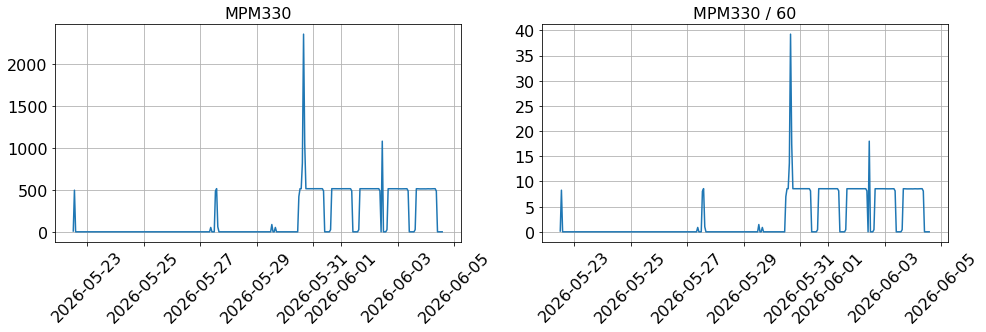

In [25]:
agg_330 = df_330.groupby("rcv_h")[["totalacpower", "activepower_60"]].sum()

dates = pd.to_datetime(agg_330.index, format="%Y%m%d-%H")

plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
plt.plot(dates, agg_330["totalacpower"].values)
plt.xticks(fontsize=16, rotation=45)
plt.yticks(fontsize=16)
plt.title("MPM330", fontsize=16)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(dates, agg_330["activepower_60"].values)
plt.title("MPM330 / 60", fontsize=16)
plt.xticks(fontsize=16, rotation=45)
plt.yticks(fontsize=16)
plt.grid(True)

plt.show()